<a href="https://colab.research.google.com/github/Elnare05/Data-science/blob/main/Dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset['quality'] = dataset['quality'].apply(lambda x: x>5)
X = dataset.iloc[:, 0:11].values
y = dataset.iloc[:, 11].values

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red.csv


In [ ]:
dataset = pd.read_csv('/content/winequality-red.csv')

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
X_train.shape

(1279, 11)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
explained_variance = pca.explained_variance_ratio_

In [ ]:
explained_variance

array([0.29871924, 0.18963528])

In [ ]:
X_test

array([[ 2.24879807e+00,  6.59532002e-01],
       [-7.69342767e-01,  4.13449767e-01],
       [ 4.36920554e-01, -1.78940128e+00],
       [ 7.58075761e-01, -1.05437875e+00],
       [ 2.03878309e+00, -2.16141278e+00],
       [ 5.78258733e-01,  5.63618094e-01],
       [ 2.89642449e-01, -7.76660710e-01],
       [ 1.19101964e-01,  5.38971513e-01],
       [-1.42000314e+00, -2.19672426e-01],
       [-7.10106445e-01,  1.19058946e+00],
       [ 4.82881709e-01, -9.89739714e-01],
       [ 8.98684100e-01, -4.74366939e-01],
       [ 8.33914375e-01, -9.13741719e-01],
       [-4.06732675e+00,  1.55591333e+00],
       [-2.50866707e+00, -4.34378786e-03],
       [-6.71913451e-02,  4.99512283e-02],
       [-4.75637779e-01, -3.03834934e+00],
       [ 1.37152688e+00, -1.28156254e+00],
       [-3.19017175e+00, -1.48849853e+00],
       [-7.32849543e-01,  4.81745940e-01],
       [-2.44105323e+00, -1.99385196e+00],
       [ 1.31958499e+00, -5.08220213e-01],
       [-1.51970520e+00, -5.57242512e-01],
       [ 3.

In [ ]:
X_train

array([[ 1.05838167e+00,  2.00394034e-01, -9.65229820e-01, ...,
         9.34818854e-01,  2.49007385e-01,  9.49834684e-01],
       [ 1.95524570e+00, -6.22339664e-02,  1.51854387e-01, ...,
         5.16801422e-02, -8.01617179e-01, -2.93892498e-01],
       [ 1.56664064e+00, -1.90710629e+00,  1.34803565e-01, ...,
         6.41509295e-01,  1.60005480e-01, -2.45938206e-02],
       ...,
       [ 5.80798029e-02,  4.66344067e-01, -3.43873791e-01, ...,
         1.60088851e-01,  1.15028947e-01, -3.26096301e-01],
       [ 3.04654159e+00, -8.75775822e-01, -2.33044869e-01, ...,
         2.57710907e-03,  1.36597586e+00,  1.34161916e+00],
       [ 1.57672581e-01,  3.65360000e+00, -4.90378317e-01, ...,
        -1.55252321e+00,  1.60708052e+00,  9.32631472e-01]])

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 77,  71],
       [ 47, 125]])

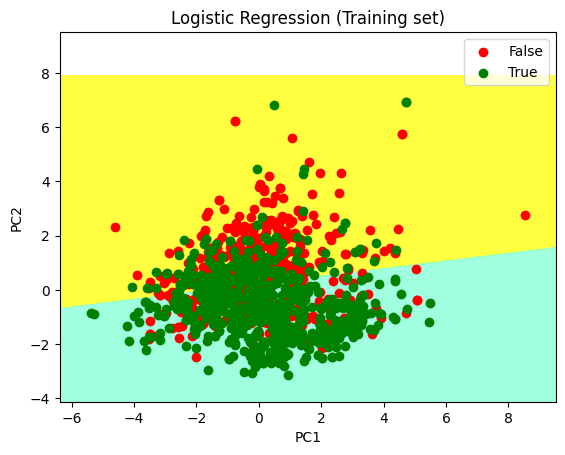

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                               stop = X_set[:, 0].max() + 1, step = 0.01),
                               np.arange(start = X_set[:, 1].min() - 1,
                               stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(),
            X2.ravel()]).T).reshape(X1.shape), alpha = 0.75,
             cmap = ListedColormap(('yellow', 'white', 'aquamarine')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X1.max())
for i, j in enumerate(np.unique(y_set)):
  plt.scatter(X_set[y_set == j, 0], X_set [y_set== j, 1],
              color = ListedColormap(('red', 'green', 'blue'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()